### Gradient Boosting

#### Background

Gradient boosting is an ensemble method with the idea that you can build a strong model by sequentially adding weak learners, where each new model focuses on the errors of the previous model.

Broad idea of gradient boosting;
1. Compute the residuals (errors) from the current models predictions
2. Fit a new tree to those residuals
3. Add tree to the ensemble, using a learning rate
4. repeat

XGBoost is a engineered version of the above process

##### **Gradient Boosting Mathematics**

Firstly, boosting is an additive expansion of learners, where the mth step is given by

$$F_m(x) = F_0(x) + \sum_{m=1}^M\eta h_m(x)$$
$$ = F_{M-1}(x) + \eta h_m(x) $$

where:
* $F_0(x)$ is the base model
* $h_m(x)$ is the mth base learner
* $\eta \in [0, 1]$ is the learn rate
* M is the number of boosting rounds


**How to find $h_m$** - the idea behind boosting is each new learner aims to improve on the areas were the current model is making mistakes. To find where the model is making mistakes, the residuals can be computed. For mean squared error loss

$$\ell_i = 0.5y_i - F(x_i))^2$$
$$\frac{\partial \ell_i}{\partial F(x_i)} = (F(x_i) - y_i)$$

This aligns with the traditional definition of a residual, as in linear regression. Extending this idea to general loss functions, we obtain the pseudo residual (for obs i)

$$r_{im} = -\left[\frac{\partial \ell(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$

Intuitively, this gradient is just asking if I nudge my model output for x_i up/down, does my loss go up or down, and if so how fast. A large gradient means currently on a steep part of the loss surface for that sample, and a small nudge in the prediction produces a big change in the loss. The algorithm prioritises correcting these.

Once these residuals are obtained, a **model is then fitted to these residuals**, treating them as the input x. This is now the mth learner, in our combined model, and this process gets repeated for as many learners as specified.

#### Gradient Boosting Implementation

Simple gradient boosting class, with customisable loss function

In [105]:
import numpy as np
import torch
import xgboost
from lightgbm import early_stopping
from nltk.app.wordnet_app import explanation
from ray.tune import grid_search
from sklearn import tree

from TimeSeries.Chapter2 import residuals


class GradientBoost:
    def __init__(self, X, y, loss_fn, learn_rate, num_learners, max_depth):
        self.X = X
        self.y = y
        self.loss_fn = loss_fn
        self.learn_rate = learn_rate
        self.num_learners = num_learners
        self.max_depth = max_depth
        self.learners = []
        self.convergence = []

    def get_gradients(self, y_pred):
        """
        Returns pseudo-residuals for loss function
        """
        y_pred = torch.tensor(y_pred, requires_grad=True, dtype=torch.float64)
        y_true = torch.tensor(self.y, dtype=torch.float64)
        loss = self.loss_fn(y_pred, y_true).sum()
        loss.backward()
        grads = y_pred.grad.numpy()
        return grads

    def fit_model(self):
        """
        fit the nth weak learner
        """

        y_pred = self.predict()
        presid = (-1) * self.get_gradients(y_pred)

        loss_val = np.mean((y_pred - self.y) ** 2)
        self.convergence.append(loss_val)

        clf = tree.DecisionTreeRegressor(max_depth=self.max_depth)
        clf.fit(self.X, presid)

        self.learners.append(clf)

        return

    def predict(self):
        """
        Return model prediction
        """
        res = np.zeros_like(self.y)
        for model in self.learners:
            res += self.learn_rate * model.predict(self.X)

        return res

    def fit(self):
        """
        Fit the specified gradient boost model
        """

        for i in range(self.num_learners):
            self.fit_model()

        return

**Loss Functions**

In [115]:
def mean_squared_error(y_pred, y_true):
    return (y_pred - y_true) ** 2

def abs_error(y_pred, y_true):
    return torch.abs(y_pred - y_true)

def huber_loss(y_pred, y_true, delta=100):
    residual = torch.abs(y_pred - y_true)
    return torch.where(
        residual < delta,
        0.5 * residual ** 2,
        delta * (residual - 0.5 * delta)
    )

def log_cosh_loss(y_pred, y_true):
    return torch.log(torch.cosh(y_pred - y_true))

def cauchy_loss(y_pred, y_true, gamma=1.0):
    residual = (y_pred - y_true) / gamma
    return torch.log(1 + residual**2)

**Convergence Analysis**

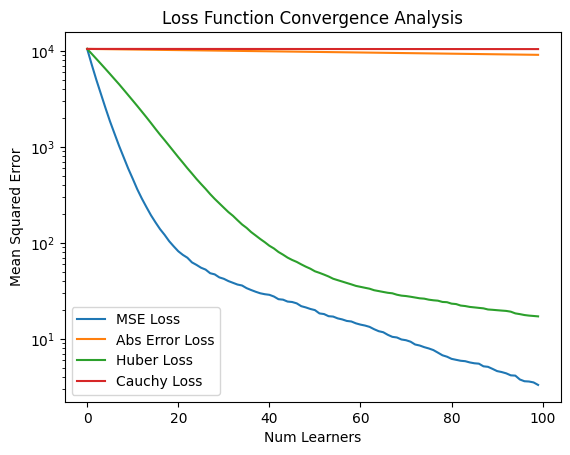

In [120]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

max_depth = 5
num_learners = 100
learn_rate = 0.1

X, y = make_regression(n_samples=500, n_features=5, noise=10, random_state=0)

gb = GradientBoost(X, y, loss_fn=mean_squared_error, learn_rate=learn_rate, num_learners=num_learners, max_depth=max_depth)
gb.fit()

plt.plot(gb.convergence, label='MSE Loss')
plt.title("Loss Function Convergence Analysis")
plt.xlabel("Num Learners")
plt.ylabel("Mean Squared Error")
plt.yscale('log')

gb = GradientBoost(X, y, loss_fn=abs_error, learn_rate=learn_rate, num_learners=num_learners, max_depth=max_depth)
gb.fit()
plt.plot(gb.convergence, label='Abs Error Loss')

gb = GradientBoost(X, y, loss_fn=huber_loss, learn_rate=learn_rate, num_learners=num_learners, max_depth=max_depth)
gb.fit()
plt.plot(gb.convergence, label='Huber Loss')

gb = GradientBoost(X, y, loss_fn=cauchy_loss, learn_rate=learn_rate, num_learners=num_learners, max_depth=max_depth)
gb.fit()
plt.plot(gb.convergence, label='Cauchy Loss')

plt.legend()

#### XGBoost

XGBoost builds off the gradient boosting idea, with the following key extensions:
1. Regularised Objective Function - penalises model complexity
2. Second Order Taylor Approximation - uses both first and second derivatives
3. Optimally engineered (parallelisation)

XGBoost generally excels at tabular/structured data, for medium sized (thousand to millions of rows) datasets

##### **XGBoost Mathematics**

For a sequential ensemble, the objective function for the tth learner on a dataset with n targets is given by

$$obj^{(t)} = \sum_{i=1}^n \ell(y_i, \hat{y_i}^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$

Where $\Omega$ is the regularisation term.


A taylor expansion can be performed on the loss function

$$\ell(y_i, \hat{y_i}^{(t-1)} + f_t(x_i)) \sim \ell(y_i, \hat{y_i}^{(t-1)}) + g_if_t(x_i) + 0.5 \cdot h_if_t(x_i)^2$$

where, $$g_i = \frac{\partial \ell(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}}$$

$$h_i = \frac{\partial^2 \ell(y_i, \hat{y}_i^{(t-1)})}{\partial (\hat{y}_i^{(t-1)})^2}$$

Removing the costants, the new objective function becomes

$$obj^{(t)} = \sum_{i=1}^n  g_if_t(x_i) + 0.5 \cdot h_if_t(x_i)^2+ \Omega(f_t)$$

**Regrouping by leaf**. As for a decision tree regressor, each leaf node will predict the same output value (i.e. $f_t(x_i)=f_t(x_j)$ if $i, j$ where in the same leaf. Grouping the objective function by leaf nodes

$$obj^{(t)} = \sum_{j=1}^T \left[ G_j w_j + \frac{1}{2}(H_j) w_j^2 \right] + \Omega(f_t)$$

where $G_j = \sum_{i \in I_j} g_i$, $H_j = \sum_{i \in I_j} h_i$, $w_j$ is the weight of leaf $j$, $T$ is the number of leaves, $I_j$ is the set of samples in leaf $j$

**XGBoost Regularisation Term** The XGBoost regularisation penalty is defined as

$$ \Omega(f_t) = \gamma T + 0.5 \lambda \sum_{j=1}^Tw_j^2 $$

The leaf weight penalty is analogous to L2 regularisation in linear regression. Penalising large coefficients aims to prevent the model from fitting noise. Substituting this regularisation term into the objective function

$$obj^{(t)} = \sum_{j=1}^T \left[ G_j w_j + \frac{1}{2}(H_j + \lambda) w_j^2 \right] + \gamma T$$


**Loss Minimisation** - within the summation the following function exists
$$Gx + 0.5(H+\lambda)x^2$$

By computing the derivative, the min can be easily obtained to occur at $\frac{-G}{H}$. Therefore

$$\min_x Gx + 0.5(H+\lambda)x^2 = -0.5 \frac{G^2}{H + \lambda}$$

Recapping, each leaf's contribution is an independent quadratic in $w_j$, and minimising each leaf seperately in closed form was performed above, giving the optimal leaf weights for each leaf. Substituting this into the objective function we obtaian

$$obj^{(t)} = -\frac{1}{2}\sum_{j=1}^T \frac{G_j^2}{H_j + \lambda} + \gamma T$$

The optimal (minimal) tree score.

**Greedy Learning** - Now that we have the optimal score for a tree structure, this can be used to evaluate the best tree structure in the first place. XGBoost builds trees greedily, one split at a time, recursively checking the "improvement" to the objective function.

The **search process** is as follows
1. Sort samples by that features value
2. Scan through all candidate split points, accumulating $G_L, H_L, G_R, H_R$ (from left and right split)
3. Record gain at each candidate point
4. Take the split with the highest gain across all features

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

In practice, sorting all samples exactly is too slow, so XGBoost uses an approximate version instead, utilising quantiles.

As a reminder, $G_L = \sum_{i \in I_j} g_i$ (i.e all predictions from that same leaf node), and $g_i$ is just the derivative of the loss w.r.t the current prediction for sample i. For MSE:
$$\ell_i = (y_i - \hat{y_i})^2$$
$$g_i = 2(\hat{y_i} - y_i)$$
Where these $\hat{y_i}, y_i$ can then be easily substituted (for MSE this coincides with the defintiion of the residual)

**Putting it all together**

1. Start with some initial prediction ($\bar{y}$)
2. For each boosting round t:
    * compute $g_i, h_i$ for every sample using the current predictions
    * fit a tree by greedily finding splits that maximise the gain
    * assign optimal leaf weights $w_j^* = -\frac{G_j}{H_j+\lambda}$
    * add tree to the ensemble
3. Prediction
$$\hat{y}_i = \hat{y}_i^{(0)} + \eta\sum_{t=1}^T f_t(x_i)$$

#### XGBoost in Practice - California Housing Prices

##### Exploratory Data Analysis

In [143]:
import kagglehub
import pandas as pd
import os

from pygments.util import split_path_re

path = kagglehub.dataset_download("camnugent/california-housing-prices")
print(os.listdir(f"{path}"))
df = pd.read_csv(f"{path}/housing.csv")

print(df.shape)
df.head()

['housing.csv']
(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [126]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

**Checking null values**. Note xgboost handles null values natively. When it encounters a missing value for a feature it's trying to split on, it tries both directions (all left or right group), and picks the better one

In [130]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [133]:
df[df['total_bedrooms'].isnull() == True]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


**Handling Non Numeric Features**

In [137]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['ocean_proximity'], dtype='object')

In [138]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

Only five different levels for the categorical feature. There is some natural strucure to the list (proximity to the ocean) for an ordinal encoding, however I believe a one-hot encoding is more appropriate, as it is dubious on the ranking between say ISLAND and NEAR OCEAN, or NEAR OCEAN vs NEAR BAY

In [144]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,0,0,0


**Feature Scaling** - as XGBoost is tree based, only ever checks if a input feature x is above or below a threshold t at each split. Hence the actual magnitude of values is irrelevant, so features on vastly different scales have no effect on split finding. Hence feature scaling isn't important for XGBoost performance.

##### **Model Fitting**

Simple out the box implementation

In [159]:
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
from sklearn.metrics import mean_squared_error


X = df.drop('median_house_value', axis=1)
y = df[['median_house_value']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = xgb.XGBRegressor()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R^2:", model.score(X_test, y_test))

Test MSE: 2334200576.0
Test R^2: 0.8249222636222839


##### **Parameter tuning**

##### **Key Parameter Overview**

**Tree Structure Parameters**
* max_depth - controls how deep each tree can grow (tradeoff between finding complex interactions, and overfitting)
* gamma - minimum gain required to make a split
* min_child_weight - Minimum sum of $H_j$ required to make a split. Effectively controls the minimum number of samples per leaf.

**Sampling Parameters**
* subsample - Idea similar as random forest, fraction of training samples used to fit tree
* colsample_bytree - fraction of features randomly sampled when building a tree

**Learning Parameters**
* n_estimators - number of boosting rounds.
* learning_rate - shrinks each tree's contribution before adding to the ensemble.
* early_stopping_rounds - lets n_estimators be automatically determined, rather than guessed

**Regularisation Parameters**
* lambda - L2 regularisation on leaf weights
* alpha - L1 regularisation on leaf weights



**Grid Search** - Test every parameter combination in a grid, using cross validation. Exhaustive, but slow.

In [153]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 6, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [20, 50, 100, 300],
}

grid_search = GridSearchCV(
    xgb.XGBRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [20, 50, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [158]:
from sklearn.metrics import mean_squared_error

best_model = grid_search.best_estimator_
test_score = mean_squared_error(y_test, best_model.predict(X_test))
print(f"Test MSE: {test_score:.2f}")
print(f"Test R^2:", best_model.score(X_test, y_test))
print(f"Best params: {grid_search.best_params_}")

Test MSE: 2144333696.00
Test R^2: 0.8391633033752441
Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}


we can see a slight improvement to the MSE, and R^2, compared to the base model.

**Early Stopping** Rather than fixing n_estimators, let the model decide when to stop.

At each iteration, the model evaluates performance on the eval_set. This is used to track when adding more learners no longer improves the model evaluation performance, an approximation of the threshold where the model moves from learning patterns in the data to overfitting

In [164]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

model = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=20)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


In [166]:
y_pred = model.predict(X_test)

print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R^2:", best_model.score(X_test, y_test))

Test MSE: 2347366400.00
Test R^2: 0.8391633033752441


**Optuna** - Framework for automating hyperparameter tuning using bayesian optimisation methods. The tuning process is as follows. Advantageous over a raw grid search, as algorithm decides if combination of hyperparameters is worth training on adaptively, and stops learning process early if there is limited improvement. This has the result of much greater computation efficiency

Objective Function - contains list of model hyperparameters, and the corresponding search value ranges.

In [171]:
from sklearn.model_selection import cross_val_score

def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5)
    }

    model = xgb.XGBRegressor(**param)
    scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

hyperparameter search - based on the objective function, create a study for the best hyperparameters

In [172]:
import optuna

study = optuna.create_study(study_name='XGB_param_study', direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=-1)

best_params = study.best_params
print(f"\nBest parameters: {best_params}")

[I 2026-04-04 15:41:23,494] A new study created in memory with name: XGB_param_study
Best trial: 4. Best value: 2.37387e+09:   1%|          | 1/100 [00:05<09:28,  5.75s/it]

[I 2026-04-04 15:41:29,210] Trial 4 finished with value: 2373874688.0 and parameters: {'max_depth': 8, 'learning_rate': 0.04740083527467841, 'n_estimators': 122, 'subsample': 0.5530282417988661, 'colsample_bytree': 0.8483478077983149, 'min_child_weight': 1, 'gamma': 2.5125095047520944}. Best is trial 4 with value: 2373874688.0.


Best trial: 4. Best value: 2.37387e+09:   2%|▏         | 2/100 [00:11<09:40,  5.92s/it]

[I 2026-04-04 15:41:35,264] Trial 3 finished with value: 2599581849.6 and parameters: {'max_depth': 3, 'learning_rate': 0.06295597880637474, 'n_estimators': 699, 'subsample': 0.5092200124971332, 'colsample_bytree': 0.755234188618362, 'min_child_weight': 8, 'gamma': 1.3693815462033132}. Best is trial 4 with value: 2373874688.0.


Best trial: 7. Best value: 2.22271e+09:   3%|▎         | 3/100 [00:16<08:27,  5.23s/it]

[I 2026-04-04 15:41:39,673] Trial 7 finished with value: 2222712601.6 and parameters: {'max_depth': 10, 'learning_rate': 0.026828795760190857, 'n_estimators': 284, 'subsample': 0.8733155012777689, 'colsample_bytree': 0.8835731084851034, 'min_child_weight': 7, 'gamma': 2.5487654434018108}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:   4%|▍         | 4/100 [00:18<06:32,  4.09s/it]

[I 2026-04-04 15:41:41,996] Trial 5 finished with value: 2410034380.8 and parameters: {'max_depth': 4, 'learning_rate': 0.04347609408446872, 'n_estimators': 916, 'subsample': 0.5329666653963896, 'colsample_bytree': 0.821647883838956, 'min_child_weight': 3, 'gamma': 1.8889377751633991}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:   5%|▌         | 5/100 [00:19<04:25,  2.79s/it]

[I 2026-04-04 15:41:42,521] Trial 10 finished with value: 3066685696.0 and parameters: {'max_depth': 3, 'learning_rate': 0.0583102613539952, 'n_estimators': 166, 'subsample': 0.8012092096272503, 'colsample_bytree': 0.9046946863130161, 'min_child_weight': 9, 'gamma': 1.6257181524987123}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:   6%|▌         | 6/100 [00:21<03:58,  2.53s/it]

[I 2026-04-04 15:41:44,543] Trial 8 finished with value: 2260512716.8 and parameters: {'max_depth': 9, 'learning_rate': 0.03164864874100942, 'n_estimators': 307, 'subsample': 0.8961344926884756, 'colsample_bytree': 0.9452481253733722, 'min_child_weight': 8, 'gamma': 0.996043830890771}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:   7%|▋         | 7/100 [00:22<03:07,  2.01s/it]

[I 2026-04-04 15:41:45,497] Trial 6 finished with value: 2327894272.0 and parameters: {'max_depth': 5, 'learning_rate': 0.028423605674074447, 'n_estimators': 859, 'subsample': 0.9675852238373983, 'colsample_bytree': 0.9787257725865155, 'min_child_weight': 1, 'gamma': 0.5640084774487797}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:   8%|▊         | 8/100 [00:23<02:38,  1.72s/it]

[I 2026-04-04 15:41:46,581] Trial 2 finished with value: 2338588108.8 and parameters: {'max_depth': 5, 'learning_rate': 0.02545929991576715, 'n_estimators': 914, 'subsample': 0.9487932318720587, 'colsample_bytree': 0.6069605940883234, 'min_child_weight': 9, 'gamma': 3.241710633771087}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:   9%|▉         | 9/100 [00:24<02:23,  1.57s/it]

[I 2026-04-04 15:41:47,839] Trial 0 finished with value: 2280657868.8 and parameters: {'max_depth': 6, 'learning_rate': 0.024688066226840416, 'n_estimators': 813, 'subsample': 0.7358004357439035, 'colsample_bytree': 0.8294614920491261, 'min_child_weight': 9, 'gamma': 0.7291821554657912}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  10%|█         | 10/100 [00:31<05:05,  3.40s/it]

[I 2026-04-04 15:41:55,322] Trial 12 finished with value: 2409203251.2 and parameters: {'max_depth': 4, 'learning_rate': 0.08531065613726237, 'n_estimators': 599, 'subsample': 0.8360756529404052, 'colsample_bytree': 0.5857683470242281, 'min_child_weight': 8, 'gamma': 3.6340051229748394}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  11%|█         | 11/100 [00:36<05:40,  3.82s/it]

[I 2026-04-04 15:42:00,098] Trial 16 finished with value: 2327367270.4 and parameters: {'max_depth': 8, 'learning_rate': 0.021795881155428028, 'n_estimators': 275, 'subsample': 0.6675872328466532, 'colsample_bytree': 0.7710439475362261, 'min_child_weight': 3, 'gamma': 1.150138718565457}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  12%|█▏        | 12/100 [00:37<04:25,  3.02s/it]

[I 2026-04-04 15:42:01,236] Trial 13 finished with value: 2715899238.4 and parameters: {'max_depth': 3, 'learning_rate': 0.020155418602698937, 'n_estimators': 988, 'subsample': 0.9450862270248093, 'colsample_bytree': 0.9054012972956687, 'min_child_weight': 3, 'gamma': 4.896960276632471}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  13%|█▎        | 13/100 [00:39<03:47,  2.62s/it]

[I 2026-04-04 15:42:02,976] Trial 9 finished with value: 2271027328.0 and parameters: {'max_depth': 7, 'learning_rate': 0.06502591093022861, 'n_estimators': 794, 'subsample': 0.9271648552888125, 'colsample_bytree': 0.5236851354029357, 'min_child_weight': 5, 'gamma': 2.9179488187783953}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  14%|█▍        | 14/100 [00:42<03:46,  2.64s/it]

[I 2026-04-04 15:42:05,646] Trial 14 finished with value: 2322154854.4 and parameters: {'max_depth': 5, 'learning_rate': 0.061656013033526684, 'n_estimators': 792, 'subsample': 0.6708775833331773, 'colsample_bytree': 0.6353136323649442, 'min_child_weight': 7, 'gamma': 3.999362024782525}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  15%|█▌        | 15/100 [00:42<02:42,  1.92s/it]

[I 2026-04-04 15:42:05,877] Trial 11 finished with value: 2433667840.0 and parameters: {'max_depth': 5, 'learning_rate': 0.018044373928089844, 'n_estimators': 916, 'subsample': 0.5398754325884659, 'colsample_bytree': 0.7463889383072068, 'min_child_weight': 10, 'gamma': 4.6088962720275015}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  16%|█▌        | 16/100 [00:43<02:08,  1.53s/it]

[I 2026-04-04 15:42:06,545] Trial 1 finished with value: 2226185062.4 and parameters: {'max_depth': 9, 'learning_rate': 0.04359327475611242, 'n_estimators': 924, 'subsample': 0.8612762322443348, 'colsample_bytree': 0.6159604815406607, 'min_child_weight': 5, 'gamma': 3.0119952728896653}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  17%|█▋        | 17/100 [00:56<07:11,  5.20s/it]

[I 2026-04-04 15:42:20,231] Trial 17 finished with value: 2236131328.0 and parameters: {'max_depth': 10, 'learning_rate': 0.013452677802008603, 'n_estimators': 430, 'subsample': 0.6879373346340996, 'colsample_bytree': 0.6769704001320304, 'min_child_weight': 5, 'gamma': 4.3558503341112065}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  18%|█▊        | 18/100 [00:58<05:42,  4.17s/it]

[I 2026-04-04 15:42:22,053] Trial 19 finished with value: 2243261772.8 and parameters: {'max_depth': 10, 'learning_rate': 0.03850637463203375, 'n_estimators': 362, 'subsample': 0.8710211401784197, 'colsample_bytree': 0.9956494980530315, 'min_child_weight': 6, 'gamma': 0.006650432003391771}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  19%|█▉        | 19/100 [01:00<04:38,  3.44s/it]

[I 2026-04-04 15:42:23,795] Trial 18 finished with value: 2378156339.2 and parameters: {'max_depth': 10, 'learning_rate': 0.011203855483438201, 'n_estimators': 371, 'subsample': 0.88242145201659, 'colsample_bytree': 0.9956305076560829, 'min_child_weight': 6, 'gamma': 4.994640257557922}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  20%|██        | 20/100 [01:02<04:13,  3.17s/it]

[I 2026-04-04 15:42:26,324] Trial 21 finished with value: 2243987763.2 and parameters: {'max_depth': 10, 'learning_rate': 0.037412382711907534, 'n_estimators': 342, 'subsample': 0.861567825872079, 'colsample_bytree': 0.9917801947592744, 'min_child_weight': 5, 'gamma': 0.01808782740245274}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  21%|██        | 21/100 [01:04<03:24,  2.59s/it]

[I 2026-04-04 15:42:27,562] Trial 20 finished with value: 2375903283.2 and parameters: {'max_depth': 10, 'learning_rate': 0.010822796146701778, 'n_estimators': 378, 'subsample': 0.8626374027496675, 'colsample_bytree': 0.9972432428776088, 'min_child_weight': 7, 'gamma': 0.2051992041591958}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  22%|██▏       | 22/100 [01:04<02:42,  2.09s/it]

[I 2026-04-04 15:42:28,484] Trial 22 finished with value: 2246271334.4 and parameters: {'max_depth': 10, 'learning_rate': 0.0376662544807625, 'n_estimators': 387, 'subsample': 0.8744407249127156, 'colsample_bytree': 0.9881157174161959, 'min_child_weight': 6, 'gamma': 0.009498219207786818}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  23%|██▎       | 23/100 [01:05<02:03,  1.60s/it]

[I 2026-04-04 15:42:28,936] Trial 15 finished with value: 2421206835.2 and parameters: {'max_depth': 10, 'learning_rate': 0.07833348686238002, 'n_estimators': 806, 'subsample': 0.6457333645271688, 'colsample_bytree': 0.5293792018881904, 'min_child_weight': 6, 'gamma': 2.244559003374172}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  24%|██▍       | 24/100 [01:13<04:23,  3.47s/it]

[I 2026-04-04 15:42:36,756] Trial 23 finished with value: 2247729203.2 and parameters: {'max_depth': 10, 'learning_rate': 0.010095914285825638, 'n_estimators': 486, 'subsample': 0.8188007793221905, 'colsample_bytree': 0.7018796644671078, 'min_child_weight': 5, 'gamma': 2.3383415533250447}. Best is trial 7 with value: 2222712601.6.


Best trial: 7. Best value: 2.22271e+09:  25%|██▌       | 25/100 [01:24<07:06,  5.69s/it]

[I 2026-04-04 15:42:47,654] Trial 25 finished with value: 2249431552.0 and parameters: {'max_depth': 9, 'learning_rate': 0.07645360931003528, 'n_estimators': 510, 'subsample': 0.7887718349881099, 'colsample_bytree': 0.690647070252263, 'min_child_weight': 6, 'gamma': 2.1754689043233717}. Best is trial 7 with value: 2222712601.6.


Best trial: 24. Best value: 2.20199e+09:  26%|██▌       | 26/100 [01:24<05:12,  4.23s/it]

[I 2026-04-04 15:42:48,461] Trial 24 finished with value: 2201993958.4 and parameters: {'max_depth': 10, 'learning_rate': 0.037610086751345556, 'n_estimators': 499, 'subsample': 0.8539252222743262, 'colsample_bytree': 0.6887873223923661, 'min_child_weight': 6, 'gamma': 2.220308552166197}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  27%|██▋       | 27/100 [01:26<04:15,  3.50s/it]

[I 2026-04-04 15:42:50,192] Trial 26 finished with value: 2246335436.8 and parameters: {'max_depth': 9, 'learning_rate': 0.07444436983033459, 'n_estimators': 532, 'subsample': 0.7867430655921797, 'colsample_bytree': 0.6715535362013346, 'min_child_weight': 5, 'gamma': 2.1849927768407396}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  28%|██▊       | 28/100 [01:27<03:13,  2.69s/it]

[I 2026-04-04 15:42:51,059] Trial 27 finished with value: 2265461094.4 and parameters: {'max_depth': 9, 'learning_rate': 0.07737579837597962, 'n_estimators': 493, 'subsample': 0.7795604686501674, 'colsample_bytree': 0.6937280674888129, 'min_child_weight': 4, 'gamma': 2.015389754131574}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  29%|██▉       | 29/100 [01:29<03:05,  2.61s/it]

[I 2026-04-04 15:42:53,487] Trial 28 finished with value: 2214427315.2 and parameters: {'max_depth': 9, 'learning_rate': 0.04809239370224279, 'n_estimators': 508, 'subsample': 0.7652165857264697, 'colsample_bytree': 0.668139425518129, 'min_child_weight': 4, 'gamma': 2.068673453615751}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  30%|███       | 30/100 [01:31<02:40,  2.30s/it]

[I 2026-04-04 15:42:55,063] Trial 30 finished with value: 2222433894.4 and parameters: {'max_depth': 9, 'learning_rate': 0.04990228971035904, 'n_estimators': 510, 'subsample': 0.7775054705211846, 'colsample_bytree': 0.685296129560888, 'min_child_weight': 4, 'gamma': 3.8288807895627706}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  31%|███       | 31/100 [01:32<02:15,  1.96s/it]

[I 2026-04-04 15:42:56,228] Trial 29 finished with value: 2224216601.6 and parameters: {'max_depth': 9, 'learning_rate': 0.049449399992555265, 'n_estimators': 539, 'subsample': 0.7653150600782643, 'colsample_bytree': 0.6874311774084433, 'min_child_weight': 4, 'gamma': 2.2052414792617627}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  32%|███▏      | 32/100 [01:35<02:36,  2.30s/it]

[I 2026-04-04 15:42:59,340] Trial 32 finished with value: 2263873075.2 and parameters: {'max_depth': 9, 'learning_rate': 0.05085541650691354, 'n_estimators': 234, 'subsample': 0.7412259981234174, 'colsample_bytree': 0.6651151290588312, 'min_child_weight': 4, 'gamma': 4.164624132290072}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  33%|███▎      | 33/100 [01:37<02:24,  2.16s/it]

[I 2026-04-04 15:43:01,121] Trial 31 finished with value: 2227337318.4 and parameters: {'max_depth': 9, 'learning_rate': 0.05087674591340407, 'n_estimators': 485, 'subsample': 0.7642648639414541, 'colsample_bytree': 0.6750253276543556, 'min_child_weight': 4, 'gamma': 4.188424692928342}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  34%|███▍      | 34/100 [01:51<06:23,  5.81s/it]

[I 2026-04-04 15:43:15,481] Trial 34 finished with value: 2273926297.6 and parameters: {'max_depth': 8, 'learning_rate': 0.04860130644137335, 'n_estimators': 587, 'subsample': 0.9969739874736822, 'colsample_bytree': 0.5528493742325635, 'min_child_weight': 4, 'gamma': 3.1051541921343127}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  35%|███▌      | 35/100 [01:55<05:27,  5.04s/it]

[I 2026-04-04 15:43:18,737] Trial 35 finished with value: 2215286169.6 and parameters: {'max_depth': 8, 'learning_rate': 0.05077187411639493, 'n_estimators': 637, 'subsample': 0.9894089105448658, 'colsample_bytree': 0.6287134864345827, 'min_child_weight': 4, 'gamma': 2.8339010366631237}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  36%|███▌      | 36/100 [01:56<04:05,  3.83s/it]

[I 2026-04-04 15:43:19,704] Trial 33 finished with value: 2222317491.2 and parameters: {'max_depth': 9, 'learning_rate': 0.048514780544435254, 'n_estimators': 618, 'subsample': 0.9940305795612376, 'colsample_bytree': 0.6408964550762938, 'min_child_weight': 4, 'gamma': 2.8935823681540747}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  37%|███▋      | 37/100 [01:57<03:15,  3.11s/it]

[I 2026-04-04 15:43:21,128] Trial 36 finished with value: 2222293785.6 and parameters: {'max_depth': 8, 'learning_rate': 0.03126139478501114, 'n_estimators': 618, 'subsample': 0.7260852299915084, 'colsample_bytree': 0.8078659188921232, 'min_child_weight': 4, 'gamma': 2.6690811045073755}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  38%|███▊      | 38/100 [01:58<02:31,  2.45s/it]

[I 2026-04-04 15:43:22,060] Trial 37 finished with value: 2291971686.4 and parameters: {'max_depth': 8, 'learning_rate': 0.04840193053115609, 'n_estimators': 624, 'subsample': 0.7378473377083917, 'colsample_bytree': 0.5652152787763164, 'min_child_weight': 2, 'gamma': 3.580059738751121}. Best is trial 24 with value: 2201993958.4.


Best trial: 24. Best value: 2.20199e+09:  39%|███▉      | 39/100 [01:59<02:05,  2.06s/it]

[I 2026-04-04 15:43:23,213] Trial 38 finished with value: 2323053158.4 and parameters: {'max_depth': 8, 'learning_rate': 0.09905774656053948, 'n_estimators': 619, 'subsample': 0.7352116837619671, 'colsample_bytree': 0.6465472219748379, 'min_child_weight': 4, 'gamma': 2.6593728938662986}. Best is trial 24 with value: 2201993958.4.


Best trial: 39. Best value: 2.19941e+09:  40%|████      | 40/100 [02:05<03:02,  3.04s/it]

[I 2026-04-04 15:43:28,563] Trial 39 finished with value: 2199407872.0 and parameters: {'max_depth': 8, 'learning_rate': 0.0315258295088451, 'n_estimators': 643, 'subsample': 0.9971151219726633, 'colsample_bytree': 0.7372676199154216, 'min_child_weight': 2, 'gamma': 2.7613491736795357}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  41%|████      | 41/100 [02:07<02:40,  2.73s/it]

[I 2026-04-04 15:43:30,451] Trial 40 finished with value: 2199643571.2 and parameters: {'max_depth': 8, 'learning_rate': 0.0317654397771746, 'n_estimators': 644, 'subsample': 0.7159542668160502, 'colsample_bytree': 0.7329082015298701, 'min_child_weight': 2, 'gamma': 2.7465717107672036}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  42%|████▏     | 42/100 [02:19<05:21,  5.54s/it]

[I 2026-04-04 15:43:42,629] Trial 41 finished with value: 2218910387.2 and parameters: {'max_depth': 7, 'learning_rate': 0.03456096298088362, 'n_estimators': 702, 'subsample': 0.7097008308903731, 'colsample_bytree': 0.7345022939047563, 'min_child_weight': 7, 'gamma': 2.767166331849616}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  43%|████▎     | 43/100 [02:21<04:23,  4.63s/it]

[I 2026-04-04 15:43:45,137] Trial 42 finished with value: 2222719129.6 and parameters: {'max_depth': 7, 'learning_rate': 0.056349226155814405, 'n_estimators': 659, 'subsample': 0.8300318635919561, 'colsample_bytree': 0.7317524683531417, 'min_child_weight': 2, 'gamma': 3.47257455932351}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  44%|████▍     | 44/100 [02:22<03:16,  3.51s/it]

[I 2026-04-04 15:43:46,040] Trial 43 finished with value: 2204403481.6 and parameters: {'max_depth': 7, 'learning_rate': 0.04278289589266874, 'n_estimators': 664, 'subsample': 0.9812572615578243, 'colsample_bytree': 0.6346422033494747, 'min_child_weight': 2, 'gamma': 2.7637519408043616}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  45%|████▌     | 45/100 [02:25<03:07,  3.41s/it]

[I 2026-04-04 15:43:49,235] Trial 46 finished with value: 2231819929.6 and parameters: {'max_depth': 7, 'learning_rate': 0.03224183643341841, 'n_estimators': 649, 'subsample': 0.6016585631054305, 'colsample_bytree': 0.7221063030346192, 'min_child_weight': 2, 'gamma': 1.652023382793948}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  47%|████▋     | 47/100 [02:26<01:35,  1.80s/it]

[I 2026-04-04 15:43:49,592] Trial 44 finished with value: 2269778329.6 and parameters: {'max_depth': 7, 'learning_rate': 0.06851873882691958, 'n_estimators': 712, 'subsample': 0.7027780171509245, 'colsample_bytree': 0.728622409024765, 'min_child_weight': 2, 'gamma': 3.533736513346261}. Best is trial 39 with value: 2199407872.0.
[I 2026-04-04 15:43:49,723] Trial 45 finished with value: 2234732339.2 and parameters: {'max_depth': 7, 'learning_rate': 0.04282409389549392, 'n_estimators': 690, 'subsample': 0.6157602589409075, 'colsample_bytree': 0.7272453801525633, 'min_child_weight': 2, 'gamma': 1.4927514890700408}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  48%|████▊     | 48/100 [02:32<02:44,  3.16s/it]

[I 2026-04-04 15:43:56,118] Trial 47 finished with value: 2200362035.2 and parameters: {'max_depth': 7, 'learning_rate': 0.043200853342345864, 'n_estimators': 692, 'subsample': 0.9186004896968831, 'colsample_bytree': 0.7365350585564303, 'min_child_weight': 2, 'gamma': 1.5968775944505544}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  49%|████▉     | 49/100 [02:35<02:39,  3.13s/it]

[I 2026-04-04 15:43:59,132] Trial 48 finished with value: 2243403827.2 and parameters: {'max_depth': 7, 'learning_rate': 0.04224063880351374, 'n_estimators': 732, 'subsample': 0.5992482386105592, 'colsample_bytree': 0.7201020933427866, 'min_child_weight': 2, 'gamma': 3.3288915098689666}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  50%|█████     | 50/100 [02:44<04:04,  4.89s/it]

[I 2026-04-04 15:44:08,187] Trial 53 finished with value: 2266666086.4 and parameters: {'max_depth': 6, 'learning_rate': 0.04073713526968861, 'n_estimators': 563, 'subsample': 0.9224047347301269, 'colsample_bytree': 0.7796788241631087, 'min_child_weight': 1, 'gamma': 1.7903102102395394}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  51%|█████     | 51/100 [02:45<02:56,  3.61s/it]

[I 2026-04-04 15:44:08,757] Trial 51 finished with value: 2254168115.2 and parameters: {'max_depth': 6, 'learning_rate': 0.04271778453175941, 'n_estimators': 708, 'subsample': 0.6331777154165362, 'colsample_bytree': 0.7821279960609073, 'min_child_weight': 2, 'gamma': 1.6614721851162695}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  53%|█████▎    | 53/100 [02:45<01:29,  1.91s/it]

[I 2026-04-04 15:44:09,304] Trial 49 finished with value: 2229193446.4 and parameters: {'max_depth': 7, 'learning_rate': 0.04111080050908501, 'n_estimators': 695, 'subsample': 0.6303480468674059, 'colsample_bytree': 0.7800346054553728, 'min_child_weight': 2, 'gamma': 1.719471677410644}. Best is trial 39 with value: 2199407872.0.
[I 2026-04-04 15:44:09,420] Trial 50 finished with value: 2246975385.6 and parameters: {'max_depth': 6, 'learning_rate': 0.042845818862205294, 'n_estimators': 745, 'subsample': 0.9177855119508764, 'colsample_bytree': 0.7816784399781805, 'min_child_weight': 2, 'gamma': 1.7409499378099478}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  54%|█████▍    | 54/100 [02:49<01:51,  2.42s/it]

[I 2026-04-04 15:44:13,043] Trial 52 finished with value: 2238268569.6 and parameters: {'max_depth': 6, 'learning_rate': 0.04100948780781682, 'n_estimators': 734, 'subsample': 0.9074611614425396, 'colsample_bytree': 0.7744469533553211, 'min_child_weight': 1, 'gamma': 1.7121513780147428}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  55%|█████▌    | 55/100 [02:50<01:27,  1.93s/it]

[I 2026-04-04 15:44:13,841] Trial 54 finished with value: 2260893900.8 and parameters: {'max_depth': 6, 'learning_rate': 0.04168950680189393, 'n_estimators': 754, 'subsample': 0.9208356381478877, 'colsample_bytree': 0.7786460888004942, 'min_child_weight': 3, 'gamma': 3.286739258335166}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  56%|█████▌    | 56/100 [02:56<02:24,  3.28s/it]

[I 2026-04-04 15:44:20,240] Trial 55 finished with value: 2238425446.4 and parameters: {'max_depth': 6, 'learning_rate': 0.042697258585148376, 'n_estimators': 760, 'subsample': 0.9188285670490459, 'colsample_bytree': 0.7783776079940322, 'min_child_weight': 1, 'gamma': 1.8792405923426116}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  57%|█████▋    | 57/100 [02:59<02:16,  3.18s/it]

[I 2026-04-04 15:44:23,218] Trial 56 finished with value: 2263735193.6 and parameters: {'max_depth': 6, 'learning_rate': 0.026469954967211603, 'n_estimators': 761, 'subsample': 0.9274918976867275, 'colsample_bytree': 0.7849471281381681, 'min_child_weight': 1, 'gamma': 1.7773499487893187}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  58%|█████▊    | 58/100 [03:04<02:37,  3.76s/it]

[I 2026-04-04 15:44:28,266] Trial 58 finished with value: 2212378854.4 and parameters: {'max_depth': 8, 'learning_rate': 0.026212588381218115, 'n_estimators': 450, 'subsample': 0.9535074204757936, 'colsample_bytree': 0.5970751082564562, 'min_child_weight': 1, 'gamma': 2.467300125246928}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  59%|█████▉    | 59/100 [03:07<02:24,  3.52s/it]

[I 2026-04-04 15:44:31,282] Trial 57 finished with value: 2263961344.0 and parameters: {'max_depth': 6, 'learning_rate': 0.027393681058204705, 'n_estimators': 752, 'subsample': 0.958735187410086, 'colsample_bytree': 0.6004997036135413, 'min_child_weight': 1, 'gamma': 2.4874398746286217}. Best is trial 39 with value: 2199407872.0.


Best trial: 39. Best value: 2.19941e+09:  60%|██████    | 60/100 [03:08<01:46,  2.65s/it]

[I 2026-04-04 15:44:31,854] Trial 61 finished with value: 2216652467.2 and parameters: {'max_depth': 8, 'learning_rate': 0.02586682454394039, 'n_estimators': 437, 'subsample': 0.9530592589812159, 'colsample_bytree': 0.6006761743798259, 'min_child_weight': 3, 'gamma': 2.414489978636789}. Best is trial 39 with value: 2199407872.0.


Best trial: 60. Best value: 2.18028e+09:  61%|██████    | 61/100 [03:18<03:13,  4.97s/it]

[I 2026-04-04 15:44:42,215] Trial 60 finished with value: 2180279756.8 and parameters: {'max_depth': 8, 'learning_rate': 0.027310915547203794, 'n_estimators': 767, 'subsample': 0.9584687927339369, 'colsample_bytree': 0.6140832235426558, 'min_child_weight': 1, 'gamma': 1.2027674559330643}. Best is trial 60 with value: 2180279756.8.


Best trial: 60. Best value: 2.18028e+09:  62%|██████▏   | 62/100 [03:19<02:17,  3.63s/it]

[I 2026-04-04 15:44:42,771] Trial 64 finished with value: 2221728384.0 and parameters: {'max_depth': 8, 'learning_rate': 0.02225013864350829, 'n_estimators': 448, 'subsample': 0.9672325034034082, 'colsample_bytree': 0.6030829225730893, 'min_child_weight': 3, 'gamma': 1.1957639632431094}. Best is trial 60 with value: 2180279756.8.
[I 2026-04-04 15:44:42,792] Trial 59 finished with value: 2199096166.4 and parameters: {'max_depth': 8, 'learning_rate': 0.026089687485739366, 'n_estimators': 762, 'subsample': 0.9550168852785088, 'colsample_bytree': 0.8105223984179715, 'min_child_weight': 1, 'gamma': 1.2397963888896513}. Best is trial 60 with value: 2180279756.8.


Best trial: 60. Best value: 2.18028e+09:  64%|██████▍   | 64/100 [03:21<01:28,  2.45s/it]

[I 2026-04-04 15:44:44,931] Trial 63 finished with value: 2196631731.2 and parameters: {'max_depth': 8, 'learning_rate': 0.02617665571075775, 'n_estimators': 575, 'subsample': 0.9465663394925957, 'colsample_bytree': 0.6004562583336923, 'min_child_weight': 3, 'gamma': 1.1780505932453065}. Best is trial 60 with value: 2180279756.8.


Best trial: 60. Best value: 2.18028e+09:  65%|██████▌   | 65/100 [03:23<01:25,  2.44s/it]

[I 2026-04-04 15:44:47,334] Trial 65 finished with value: 2201832780.8 and parameters: {'max_depth': 8, 'learning_rate': 0.028837561297436202, 'n_estimators': 439, 'subsample': 0.9586467303894041, 'colsample_bytree': 0.5922106267876897, 'min_child_weight': 3, 'gamma': 2.4117607420649927}. Best is trial 60 with value: 2180279756.8.


Best trial: 60. Best value: 2.18028e+09:  66%|██████▌   | 66/100 [03:26<01:25,  2.51s/it]

[I 2026-04-04 15:44:49,968] Trial 62 finished with value: 2180921881.6 and parameters: {'max_depth': 8, 'learning_rate': 0.025852501399958663, 'n_estimators': 853, 'subsample': 0.9634728970074264, 'colsample_bytree': 0.6013264210212235, 'min_child_weight': 3, 'gamma': 1.179807303424932}. Best is trial 60 with value: 2180279756.8.


Best trial: 60. Best value: 2.18028e+09:  67%|██████▋   | 67/100 [03:46<03:55,  7.15s/it]

[I 2026-04-04 15:45:09,568] Trial 67 finished with value: 2193780966.4 and parameters: {'max_depth': 8, 'learning_rate': 0.017998947079613782, 'n_estimators': 847, 'subsample': 0.9777400038719304, 'colsample_bytree': 0.7499607859213873, 'min_child_weight': 3, 'gamma': 2.9918746245315564}. Best is trial 60 with value: 2180279756.8.


Best trial: 60. Best value: 2.18028e+09:  68%|██████▊   | 68/100 [03:46<02:49,  5.30s/it]

[I 2026-04-04 15:45:10,133] Trial 69 finished with value: 2236616320.0 and parameters: {'max_depth': 8, 'learning_rate': 0.017990352423566544, 'n_estimators': 579, 'subsample': 0.9785654676545782, 'colsample_bytree': 0.7519780505866307, 'min_child_weight': 1, 'gamma': 0.7021885676010298}. Best is trial 60 with value: 2180279756.8.
[I 2026-04-04 15:45:10,134] Trial 66 finished with value: 2209287526.4 and parameters: {'max_depth': 8, 'learning_rate': 0.017351885810299325, 'n_estimators': 867, 'subsample': 0.9465536982141945, 'colsample_bytree': 0.8612707544077323, 'min_child_weight': 3, 'gamma': 1.250318619188608}. Best is trial 60 with value: 2180279756.8.


Best trial: 60. Best value: 2.18028e+09:  70%|███████   | 70/100 [03:50<01:55,  3.84s/it]

[I 2026-04-04 15:45:14,141] Trial 72 finished with value: 2237089177.6 and parameters: {'max_depth': 8, 'learning_rate': 0.017073340767117418, 'n_estimators': 577, 'subsample': 0.9417284058253876, 'colsample_bytree': 0.8515940703836832, 'min_child_weight': 3, 'gamma': 0.7321698766995235}. Best is trial 60 with value: 2180279756.8.


Best trial: 68. Best value: 2.17978e+09:  71%|███████   | 71/100 [03:57<02:09,  4.46s/it]

[I 2026-04-04 15:45:20,491] Trial 68 finished with value: 2179784192.0 and parameters: {'max_depth': 8, 'learning_rate': 0.022856257598896083, 'n_estimators': 853, 'subsample': 0.9823421244121604, 'colsample_bytree': 0.6191111093108809, 'min_child_weight': 1, 'gamma': 1.1250737082873956}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  72%|███████▏  | 72/100 [04:00<01:55,  4.11s/it]

[I 2026-04-04 15:45:23,644] Trial 70 finished with value: 2227422617.6 and parameters: {'max_depth': 8, 'learning_rate': 0.016829325953963997, 'n_estimators': 857, 'subsample': 0.9745142998978704, 'colsample_bytree': 0.8611723377350289, 'min_child_weight': 1, 'gamma': 0.6851939300895437}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  73%|███████▎  | 73/100 [04:01<01:32,  3.42s/it]

[I 2026-04-04 15:45:25,218] Trial 71 finished with value: 2197616819.2 and parameters: {'max_depth': 8, 'learning_rate': 0.016776043279338418, 'n_estimators': 841, 'subsample': 0.8961785618432573, 'colsample_bytree': 0.7531344103597333, 'min_child_weight': 1, 'gamma': 0.9961407184205271}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  74%|███████▍  | 74/100 [04:08<01:54,  4.39s/it]

[I 2026-04-04 15:45:32,070] Trial 73 finished with value: 2209441561.6 and parameters: {'max_depth': 8, 'learning_rate': 0.017260520664879347, 'n_estimators': 856, 'subsample': 0.9382826830465, 'colsample_bytree': 0.8534255297117486, 'min_child_weight': 1, 'gamma': 0.7436495485702799}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  75%|███████▌  | 75/100 [04:26<03:21,  8.07s/it]

[I 2026-04-04 15:45:49,444] Trial 75 finished with value: 2190033996.8 and parameters: {'max_depth': 8, 'learning_rate': 0.022652992324424737, 'n_estimators': 851, 'subsample': 0.9347794298075017, 'colsample_bytree': 0.8177704781755909, 'min_child_weight': 3, 'gamma': 0.9605469251233105}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  76%|███████▌  | 76/100 [04:26<02:23,  5.97s/it]

[I 2026-04-04 15:45:50,247] Trial 74 finished with value: 2215415859.2 and parameters: {'max_depth': 8, 'learning_rate': 0.0171021376697946, 'n_estimators': 859, 'subsample': 0.9383200768117927, 'colsample_bytree': 0.8739949691333626, 'min_child_weight': 3, 'gamma': 0.47941350984067166}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  77%|███████▋  | 77/100 [04:27<01:40,  4.36s/it]

[I 2026-04-04 15:45:50,736] Trial 76 finished with value: 2209616384.0 and parameters: {'max_depth': 8, 'learning_rate': 0.014264527813002604, 'n_estimators': 864, 'subsample': 0.9398685400665622, 'colsample_bytree': 0.8149244028045244, 'min_child_weight': 3, 'gamma': 0.8644522010599968}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  78%|███████▊  | 78/100 [04:36<02:06,  5.76s/it]

[I 2026-04-04 15:45:59,860] Trial 78 finished with value: 2227958937.6 and parameters: {'max_depth': 8, 'learning_rate': 0.022606790960928484, 'n_estimators': 849, 'subsample': 0.981030357222695, 'colsample_bytree': 0.5725207485720495, 'min_child_weight': 1, 'gamma': 1.0650895623007612}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  79%|███████▉  | 79/100 [04:37<01:34,  4.48s/it]

[I 2026-04-04 15:46:01,289] Trial 79 finished with value: 2229796352.0 and parameters: {'max_depth': 8, 'learning_rate': 0.023010822188676748, 'n_estimators': 833, 'subsample': 0.8913905651464168, 'colsample_bytree': 0.5787719055435627, 'min_child_weight': 1, 'gamma': 0.8651281579184875}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  80%|████████  | 80/100 [04:39<01:13,  3.66s/it]

[I 2026-04-04 15:46:02,959] Trial 77 finished with value: 2199624012.8 and parameters: {'max_depth': 9, 'learning_rate': 0.022993043640302132, 'n_estimators': 843, 'subsample': 0.8900153159160473, 'colsample_bytree': 0.820547637224337, 'min_child_weight': 1, 'gamma': 1.0410592423869685}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  81%|████████  | 81/100 [04:52<02:02,  6.45s/it]

[I 2026-04-04 15:46:16,046] Trial 80 finished with value: 2230683673.6 and parameters: {'max_depth': 9, 'learning_rate': 0.02342496763129044, 'n_estimators': 960, 'subsample': 0.8938556943024759, 'colsample_bytree': 0.5084492983608008, 'min_child_weight': 1, 'gamma': 0.9667351715770474}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  82%|████████▏ | 82/100 [04:59<01:57,  6.55s/it]

[I 2026-04-04 15:46:22,710] Trial 81 finished with value: 2234212147.2 and parameters: {'max_depth': 9, 'learning_rate': 0.0208719645241026, 'n_estimators': 960, 'subsample': 0.8957963008649915, 'colsample_bytree': 0.576582576609771, 'min_child_weight': 1, 'gamma': 0.9491920350487678}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  83%|████████▎ | 83/100 [05:12<02:22,  8.40s/it]

[I 2026-04-04 15:46:35,570] Trial 84 finished with value: 2225905561.6 and parameters: {'max_depth': 9, 'learning_rate': 0.022157559958073086, 'n_estimators': 970, 'subsample': 0.8992412276982675, 'colsample_bytree': 0.5052918814433821, 'min_child_weight': 10, 'gamma': 0.9834128902856846}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  84%|████████▍ | 84/100 [05:12<01:35,  5.96s/it]

[I 2026-04-04 15:46:35,807] Trial 88 finished with value: 2550548736.0 and parameters: {'max_depth': 4, 'learning_rate': 0.019655018877193894, 'n_estimators': 906, 'subsample': 0.9968994926493154, 'colsample_bytree': 0.6132612163060626, 'min_child_weight': 2, 'gamma': 1.3744925218831892}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  85%|████████▌ | 85/100 [05:16<01:20,  5.40s/it]

[I 2026-04-04 15:46:39,812] Trial 82 finished with value: 2235223654.4 and parameters: {'max_depth': 9, 'learning_rate': 0.02270270418384037, 'n_estimators': 967, 'subsample': 0.8917377714582381, 'colsample_bytree': 0.5588800992095073, 'min_child_weight': 1, 'gamma': 0.9226478051058057}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  87%|████████▋ | 87/100 [05:21<00:47,  3.63s/it]

[I 2026-04-04 15:46:44,300] Trial 85 finished with value: 2182310963.2 and parameters: {'max_depth': 9, 'learning_rate': 0.023348756560543756, 'n_estimators': 937, 'subsample': 0.8883305714281156, 'colsample_bytree': 0.8302929543345866, 'min_child_weight': 10, 'gamma': 1.4062921432427473}. Best is trial 68 with value: 2179784192.0.
[I 2026-04-04 15:46:44,466] Trial 83 finished with value: 2196550963.2 and parameters: {'max_depth': 9, 'learning_rate': 0.022858707990530216, 'n_estimators': 962, 'subsample': 0.896126861914784, 'colsample_bytree': 0.8268027995145677, 'min_child_weight': 1, 'gamma': 0.9872626146289788}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  88%|████████▊ | 88/100 [05:26<00:51,  4.29s/it]

[I 2026-04-04 15:46:50,248] Trial 87 finished with value: 2181657241.6 and parameters: {'max_depth': 9, 'learning_rate': 0.013492201731243032, 'n_estimators': 962, 'subsample': 0.9008182895916564, 'colsample_bytree': 0.8321891225981431, 'min_child_weight': 10, 'gamma': 1.3632964263252823}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  89%|████████▉ | 89/100 [05:31<00:48,  4.44s/it]

[I 2026-04-04 15:46:55,140] Trial 86 finished with value: 2225562803.2 and parameters: {'max_depth': 9, 'learning_rate': 0.020534367138080073, 'n_estimators': 942, 'subsample': 0.9668853268894244, 'colsample_bytree': 0.8351702474113777, 'min_child_weight': 1, 'gamma': 1.3596469333075223}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  90%|█████████ | 90/100 [05:41<01:00,  6.09s/it]

[I 2026-04-04 15:47:05,074] Trial 90 finished with value: 2240521753.6 and parameters: {'max_depth': 7, 'learning_rate': 0.034792706866795656, 'n_estimators': 782, 'subsample': 0.998415253803676, 'colsample_bytree': 0.5493745434548086, 'min_child_weight': 2, 'gamma': 1.3188914153625473}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  91%|█████████ | 91/100 [05:43<00:42,  4.75s/it]

[I 2026-04-04 15:47:06,713] Trial 89 finished with value: 2189779123.2 and parameters: {'max_depth': 9, 'learning_rate': 0.013675405970437843, 'n_estimators': 895, 'subsample': 0.9970949497000062, 'colsample_bytree': 0.6195576781037566, 'min_child_weight': 9, 'gamma': 1.3683284606292863}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  92%|█████████▏| 92/100 [05:43<00:28,  3.50s/it]

[I 2026-04-04 15:47:07,306] Trial 91 finished with value: 2268199270.4 and parameters: {'max_depth': 7, 'learning_rate': 0.014173990151190403, 'n_estimators': 805, 'subsample': 0.9685172015897957, 'colsample_bytree': 0.7992501311080157, 'min_child_weight': 3, 'gamma': 1.3399890803685697}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  93%|█████████▎| 93/100 [05:47<00:24,  3.54s/it]

[I 2026-04-04 15:47:10,834] Trial 92 finished with value: 2225690316.8 and parameters: {'max_depth': 7, 'learning_rate': 0.029896511567746968, 'n_estimators': 793, 'subsample': 0.9671545227056738, 'colsample_bytree': 0.8335600930554798, 'min_child_weight': 2, 'gamma': 1.3571786843012916}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  94%|█████████▍| 94/100 [05:54<00:27,  4.51s/it]

[I 2026-04-04 15:47:17,657] Trial 93 finished with value: 2248173030.4 and parameters: {'max_depth': 7, 'learning_rate': 0.01364873290381996, 'n_estimators': 894, 'subsample': 0.852296165361486, 'colsample_bytree': 0.7992635495270659, 'min_child_weight': 5, 'gamma': 1.4053555292205022}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  95%|█████████▌| 95/100 [06:02<00:27,  5.52s/it]

[I 2026-04-04 15:47:25,589] Trial 94 finished with value: 2208763392.0 and parameters: {'max_depth': 9, 'learning_rate': 0.014128161697064611, 'n_estimators': 902, 'subsample': 0.9679093146344518, 'colsample_bytree': 0.9052305530443971, 'min_child_weight': 9, 'gamma': 0.48981164121770515}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  96%|█████████▌| 96/100 [06:05<00:19,  4.97s/it]

[I 2026-04-04 15:47:29,264] Trial 95 finished with value: 2202974028.8 and parameters: {'max_depth': 9, 'learning_rate': 0.013286934101318364, 'n_estimators': 892, 'subsample': 0.8750041933718371, 'colsample_bytree': 0.9075785881039433, 'min_child_weight': 9, 'gamma': 1.437771637019532}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  97%|█████████▋| 97/100 [06:10<00:14,  4.93s/it]

[I 2026-04-04 15:47:34,110] Trial 96 finished with value: 2196551987.2 and parameters: {'max_depth': 10, 'learning_rate': 0.013865125093017665, 'n_estimators': 897, 'subsample': 0.8594906078459742, 'colsample_bytree': 0.9064034022344766, 'min_child_weight': 10, 'gamma': 0.31143115801278354}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  98%|█████████▊| 98/100 [06:12<00:08,  4.01s/it]

[I 2026-04-04 15:47:35,958] Trial 98 finished with value: 2203504409.6 and parameters: {'max_depth': 9, 'learning_rate': 0.014312832336254975, 'n_estimators': 895, 'subsample': 0.8502871796243942, 'colsample_bytree': 0.8983493736095038, 'min_child_weight': 10, 'gamma': 0.47572921909094057}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09:  99%|█████████▉| 99/100 [06:12<00:02,  2.90s/it]

[I 2026-04-04 15:47:36,286] Trial 99 finished with value: 2195414681.6 and parameters: {'max_depth': 9, 'learning_rate': 0.02847118806455371, 'n_estimators': 894, 'subsample': 0.8480867936098908, 'colsample_bytree': 0.833436019244401, 'min_child_weight': 9, 'gamma': 0.45863017106581716}. Best is trial 68 with value: 2179784192.0.


Best trial: 68. Best value: 2.17978e+09: 100%|██████████| 100/100 [06:13<00:00,  3.74s/it]

[I 2026-04-04 15:47:37,018] Trial 97 finished with value: 2194461491.2 and parameters: {'max_depth': 10, 'learning_rate': 0.013513078338125291, 'n_estimators': 893, 'subsample': 0.8488318872334317, 'colsample_bytree': 0.9037624839036891, 'min_child_weight': 9, 'gamma': 0.37302345696664396}. Best is trial 68 with value: 2179784192.0.

Best parameters: {'max_depth': 8, 'learning_rate': 0.022856257598896083, 'n_estimators': 853, 'subsample': 0.9823421244121604, 'colsample_bytree': 0.6191111093108809, 'min_child_weight': 1, 'gamma': 1.1250737082873956}


Parameter Visualisations

In [173]:
import optuna.visualization as vis

display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

In [175]:
best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R^2:", best_model.score(X_test, y_test))

Test MSE: 2115886464.00
Test R^2: 0.8412970304489136


##### **Model Evaluation**

Statistical Metrics

In [178]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.4f}")

RMSE: 45998.77
MAE: 30301.43
R^2: 0.8413


Residual Analysis

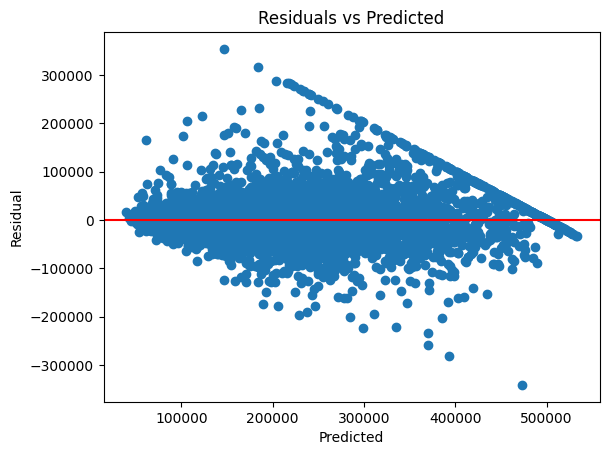

In [189]:
residuals = np.array(y_test).T - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

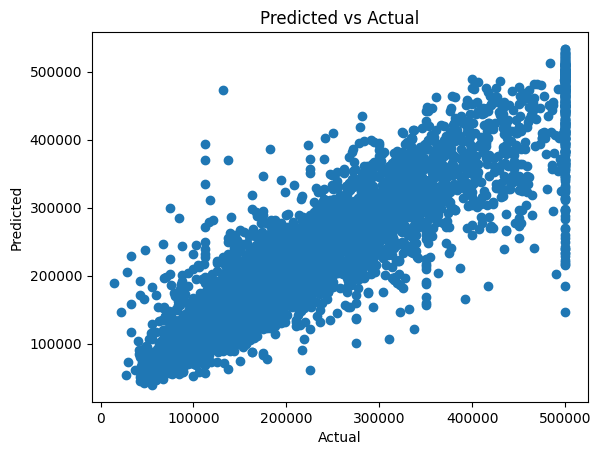

In [193]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()

Weird behaviour happening around $500,000. This is a quirk in the California Housing Dataset, where the census hard capped the median house price at 500,000, so theres a large cluster of clipped values at that ceiling.

A standard fix here can be to remove those points, as they are not real values.

Learning Curves - used to diagnose overfitting/underfitting

Text(0.5, 1.0, 'Learning Curves')

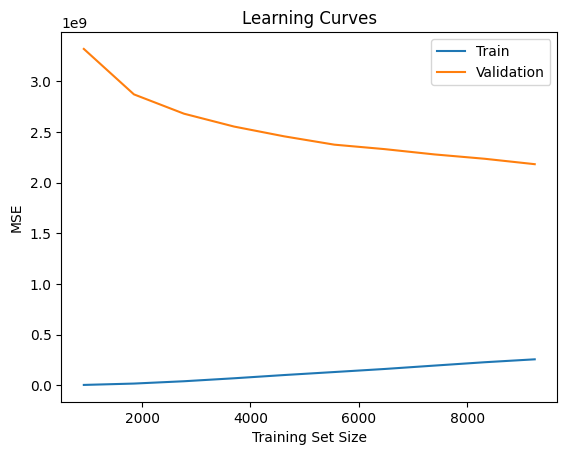

In [195]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(**best_params),
    X_train, y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1, 10)
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, -val_scores.mean(axis=1), label='Validation')
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.legend()
plt.title("Learning Curves")

for the learning curve, the train and validation are still far from convergence. This is an indicator of potential overfitting, and a lack of data (since val curve is still declining)

Permutation Importance

Analyses how much does a model performance degrade when a features information is destroyed. Similar idea to LOOCV

tells you how much each feature matters, however not in each direction

In [199]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    scoring='neg_mean_squared_error',
    random_state=0
)

feature_names = X_test.columns

for i in result.importances_mean.argsort()[::-1]:
    print(f"{feature_names[i]:<30}: {result.importances_mean[i]:.4f} "
          f"+/- {result.importances_std[i]:.4f}")

longitude                     : 5777741337.6000 +/- 68189260.5961
median_income                 : 5426178688.0000 +/- 100673938.5603
latitude                      : 5193974144.0000 +/- 82738244.7309
ocean_proximity_INLAND        : 1484543027.2000 +/- 44557641.7058
total_rooms                   : 1451902003.2000 +/- 29309341.2079
population                    : 1278306816.0000 +/- 28843739.8495
housing_median_age            : 439791334.4000 +/- 27780352.0854
total_bedrooms                : 373713561.6000 +/- 11272880.8147
households                    : 282631833.6000 +/- 10990056.5679
ocean_proximity_NEAR OCEAN    : 103792153.6000 +/- 6445485.6349
ocean_proximity_NEAR BAY      : 36050252.8000 +/- 4600620.5741
ocean_proximity_ISLAND        : 207590.4000 +/- 5402.9951


The high ranking of latitude and longitude imply house prices are extremely location dependent

SHAP

Shap considers every single possible subset of features, to measure each features marginal contribution. Mathematically

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F| - |S| - 1)!}{|F|!} \left[ v(S \cup \{i\}) - v(S) \right]$$

Where:
- $F$ is the full set of features
- $S$ is a subset of features not containing feature $i$
- $v(S)$ is the model's expected output using only features in $S$
- $v(S \cup \{i\}) - v(S)$ is the marginal contribution of adding feature $i$ to coalition $S$
- The fraction is a weighting term that averages over all possible orderings

Breaking the formula down. The weighting term $\frac{|S|!(|F| - |S| - 1)!}{|F|!}$ makes the weights mathematically identical to averaging over all $|F|!$ orderings uniformly. This ensures every ordering of features treated equally.

**Four Major Axioms**

1. **Efficiency** — contributions sum to the total payout:
$$\sum_{i \in F} \phi_i = v(F) - v(\emptyset)$$

2. **Symmetry** — if two features contribute equally to every coalition they should get equal attribution:
$$v(S \cup \{i\}) = v(S \cup \{j\}) \forall S \implies \phi_i = \phi_j$$

3. **Dummy** — if a feature contributes nothing to any coalition its Shapley value is zero:
$$v(S \cup \{i\}) = v(S) \forall S \implies \phi_i = 0$$

4. **Linearity** — if you combine two games the Shapley values add:
$$\phi_i(v + w) = \phi_i(v) + \phi_i(w)$$

The efficiency axiom is just saying that the SHAP values must exactly account for the full prediction. Nothing is left unexplained.

$$\sum_{i \in F} \phi_i = \hat{y} - E(\hat{y})$$

If the model predicts 300k, but the base $E(\hat{y})$ predicts 200k, then the SHAP values must sum to exactly 100k. This gives a complete, exact accounting of ecery individual prediction

In [202]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

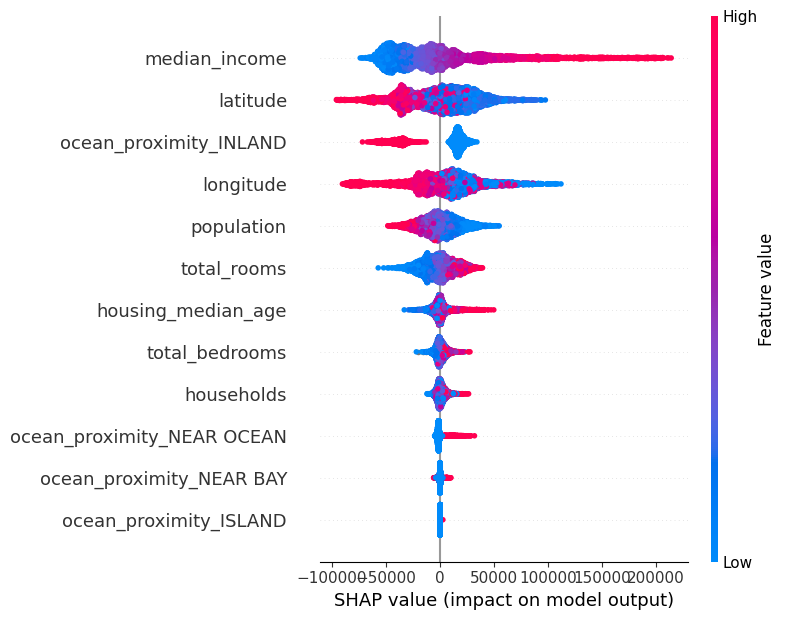

In [203]:
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

interpreting this plot, each dot corresponds to one sample - Red = high, blue = low. x position is the shap value. This enables easy visualisation of systematic trends. For example with median income, a high value generally has a very large impact on the model, increasing the predicted price.

Similarly if the ocean_proximity indicator, a 1 value corresponds to a negative SHAP value, having the effect of reducing the predicted median house price.

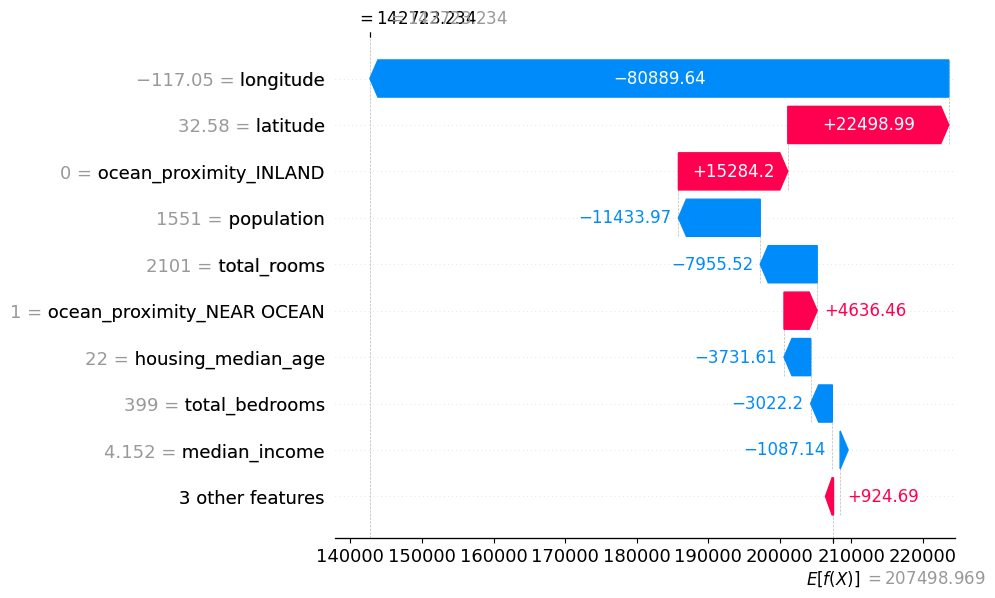

In [207]:
shap.waterfall_plot(explainer(X_test)[0])

waterfall plot can be used to analyse why the model came to its conclusion for an input feature. For the first x_test variable, we can see that the longitude caused a significant decrease in the predicted median house value.

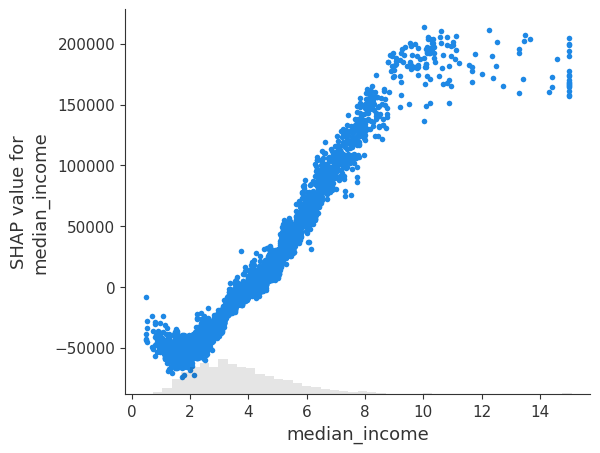

In [214]:
explanation = explainer(X_test)

shap.plots.scatter(explanation[:, 'median_income'])

The dependence plot can be used to visualise how a specific feature effects the prediction outcome across its range.

Additional - latitude and longitude visualisation

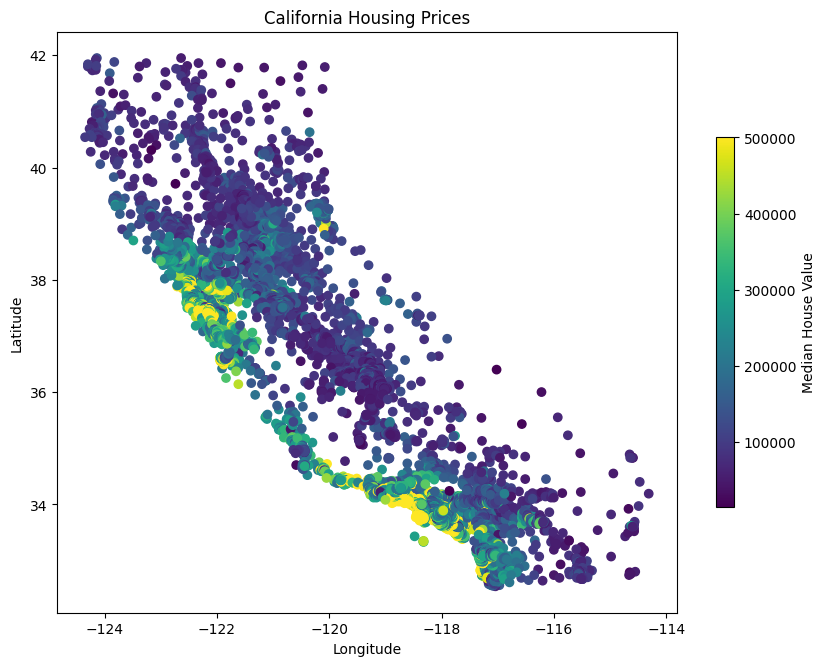

In [225]:
import geopandas as gpd

df_sub = df[['latitude', 'longitude', 'median_house_value']]

gdf = gpd.GeoDataFrame(
    df_sub,
    geometry=gpd.points_from_xy(df_sub.longitude, df_sub.latitude)
)

fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(column='median_house_value', cmap='viridis', legend=True,
         legend_kwds={'label': 'Median House Value', 'shrink': 0.6},
         ax=ax)

ax.set_title('California Housing Prices')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()